In [1]:
# imports

import pandas as pd
import numpy as np
import json
from pandas import json_normalize
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.spatial import distance_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
import matplotlib.cm as cm
import os
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cm.Dark2.colors)
from TrackReconstruction_functions import *


In [2]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/nodiff_full.jsonl", lines=True)
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/5.0percent_full.jsonl", lines=True)
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/0.1percent_full.jsonl", lines=True)

nodiff_full_df.head()

,file,event_id,vertex,energies,vectors_true,cos12_true,vectors_reco,cos12_reco,vertex_1mm,vectors_1mm,...,cos12_2mm,vertex_3mm,vectors_3mm,cos12_3mm,vertex_4mm,vectors_4mm,cos12_4mm,vertex_5mm,vectors_5mm,cos12_5mm
0,events_45_135_nexus_234.h5,28200,"[89.17036437988281, -254.9182891845703, 770.67...","[1.781910896301269, 1.218094229698181]","[{'endpoint': [89.00848481290471, -254.4816803...",-0.454866,"[{'endpoint': [79.4565200805664, -257.61080932...",-0.487951,"[88.86144002208489, -255.10006462982318, 769.7...","[{'endpoint': [79.4565200805664, -257.61080932...",...,-0.618403,"[91.09571450968498, -252.8572828947578, 771.69...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.224220,"[87.67924110127412, -258.12826677466614, 768.8...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.563375,"[91.24455884378584, -250.36886987136333, 770.6...","[{'endpoint': [79.4565200805664, -257.61080932...",-0.181575
1,events_45_135_nexus_234.h5,28201,"[-54.74333572387695, -2966.484619140625, 1998....","[1.379248261451721, 1.6207501888275142]","[{'endpoint': [-55.02584569747405, -2965.93378...",0.454660,"[{'endpoint': [-45.209869384765625, -2955.6706...",0.492365,"[-54.91854858746494, -2966.686053230591, 1999....","[{'endpoint': [-45.209869384765625, -2955.6706...",...,0.407536,"[-56.511926764574234, -2965.4762509016687, 199...","[{'endpoint': [-45.209869384765625, -2955.6706...",0.539460,"[-53.57113195968768, -2963.9692040412474, 2001...","[{'endpoint': [-45.209869384765625, -2955.6706...",0.248632,"[-53.12605900646379, -2966.173092952516, 1993....","[{'endpoint': [-57.89631652832031, -2961.35180...",0.623635
2,events_45_135_nexus_234.h5,28202,"[314.8579406738281, 2711.10498046875, -552.675...","[1.730754613876342, 1.269249081611633]","[{'endpoint': [315.17700085837276, 2710.841630...",0.901132,"[{'endpoint': [318.6174011230469, 2706.1215820...",0.977016,"[314.98840423433916, 2711.7930282911852, -551....","[{'endpoint': [318.6174011230469, 2706.1215820...",...,0.962188,"[314.8621330057856, 2710.2448115933494, -549.8...","[{'endpoint': [318.6174011230469, 2706.1215820...",0.959663,"[311.09715809001284, 2712.4640880362854, -552....","[{'endpoint': [319.6283874511719, 2705.7192382...",0.959133,"[313.05188592239057, 2715.531212507787, -554.1...","[{'endpoint': [319.6283874511719, 2705.7192382...",0.905683
3,events_45_135_nexus_234.h5,28203,"[373.4661560058594, 349.9651794433594, -638.76...","[1.362069845199585, 1.637934684753418]","[{'endpoint': [373.3819762052033, 349.98017940...",-0.087843,"[{'endpoint': [362.6803894042969, 367.66485595...",-0.100428,"[372.5930854145892, 349.886021190455, -638.283...","[{'endpoint': [362.6803894042969, 367.66485595...",...,0.040092,"[372.07618050437156, 350.1919811462794, -636.1...","[{'endpoint': [362.6803894042969, 367.66485595...",-0.053132,"[372.2966744914987, 349.7984995025873, -634.94...","[{'endpoint': [362.6803894042969, 367.66485595...",0.036802,"[376.15421895038344, 346.51332284672463, -636....","[{'endpoint': [370.51177978515625, 354.9004516...",0.497040
4,events_45_135_nexus_234.h5,28204,"[-115.1897201538086, 1587.96142578125, -2769.7...","[1.736728310585022, 1.263268947601318]","[{'endpoint': [-115.11645010723716, 1587.47077...",-0.290744,"[{'endpoint': [-112.67630767822266, 1581.93530...",-0.228110,"[-115.20885679729112, 1587.5336735901299, -276...","[{'endpoint': [-112.67630767822266, 1581.93530...",...,-0.280238,"[-114.42494850108008, 1590.188371065965, -2771...","[{'endpoint': [-101.98085021972656, 1599.75476...",-0.193759,"[-115.00556518099947, 1585.3430816315845, -276...","[{'endpoint': [-112.67630767822266, 1581.93530...",-0.308333,"[-112.91921230855671, 1587.1515403465978, -277...","[{'endpoint': [-101.98085021972656, 1599.75476...",-0.042227


In [18]:
label_dir = "/home/rei/NEXT/vertex_ML/yolo_data/detect/predict/labels"
vertex_dict = {}
for file in os.listdir(label_dir):
    eid = file.split("_")[1]
    diffusion = file.split("_")[6]
    print(f"found event {eid} with diffusion {diffusion}")
    dims = file.split("_")[7]
    dim_1 = dims[0] 
    dim_2 = dims[1]
    key = f"{eid}_{diffusion}"
    if key not in vertex_dict:
        vertex_dict[key] = {
            "diffusion": diffusion,
            "x_true": None,
            "y_true": None,
            "z_true": None,
            f"{dim_1}_pred": [],
            f"{dim_2}_pred": [],
            "confidence": []
        }

    if diffusion == "5.0percent":
        df = five_full_df
    elif diffusion == "0.1percent":
        df = zero_one_full_df
    else:
        df = nodiff_full_df
    for index, row in df.iterrows():
        if str(row["event_id"]) == eid:
            true_vertex = row["vertex"]
            print(f"found match!")

    image_dims = (396, 394)
    
    file_path = os.path.join(label_dir, file)
    with open(file_path, "r") as f:
        lines = f.readlines()
    best_line = None
    best_conf = -1
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 6:
            confidence = float(parts[-1])
        else:
            confidence = 1.0
    
        if confidence > best_conf:
            best_conf = confidence
            best_line = parts
    
    if best_line:
        #format : class x_center y_center box_width box_height
        x_rel, y_rel = float(best_line[1]), float(best_line[2])
        x_px, y_px = x_rel*image_dims[0], y_rel*image_dims[1]

        vertex_dict[key]["x_true"] = true_vertex[0]
        vertex_dict[key]["y_true"] = true_vertex[1]
        vertex_dict[key]["z_true"] = true_vertex[2]
    
        vertex_dict[key][f"{dim_1}_pred"].append(x_px)
        vertex_dict[key][f"{dim_2}_pred"].append(y_px)
    
        vertex_dict[key]["confidence"].append(best_conf)

        print(vertex_dict[key])

found event 93816 with diffusion nodiff
found match!
{'diffusion': 'nodiff', 'x_true': -363.2916564941406, 'y_true': -1136.418701171875, 'z_true': -967.0194091796875, 'y_pred': [162.912024], 'z_pred': [164.70184999999998], 'confidence': [1.0]}
found event 75855 with diffusion nodiff
found match!
{'diffusion': 'nodiff', 'x_true': -2336.7919921875, 'y_true': -1873.865234375, 'z_true': 2289.679931640625, 'x_pred': [19.4228496], 'z_pred': [71.628412], 'confidence': [1.0]}
found event 97712 with diffusion nodiff
found match!
{'diffusion': 'nodiff', 'x_true': 2474.824951171875, 'y_true': 1177.475341796875, 'z_true': -2777.123291015625, 'x_pred': [72.22089600000001], 'z_pred': [157.806062], 'confidence': [1.0]}
found event 96219 with diffusion nodiff
found match!
{'diffusion': 'nodiff', 'x_true': -2017.4044189453125, 'y_true': 1264.86669921875, 'z_true': -2455.938232421875, 'x_pred': [247.265172], 'y_pred': [168.877068], 'confidence': [1.0]}
found event 89860 with diffusion nodiff
found match

KeyboardInterrupt: 

In [21]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

int64
0    93720
1    93720
2    93720
3    93720
4    93720
Name: event_id, dtype: int64
        event_id           x            y           z      time    energy  \
547461     93816 -362.666748 -1136.082886 -967.723877  0.003476  0.000705   
547462     93816 -362.049896 -1135.733032 -968.428833  0.006952  0.000097   
547463     93816 -361.492584 -1135.327637 -969.152161  0.010425  0.001989   
547464     93816 -360.957520 -1134.922241 -969.891235  0.013897  0.001557   
547465     93816 -360.427124 -1134.505981 -970.627686  0.017369  0.000142   

       label  particle_id  hit_id  
547461   GAS            2       0  
547462   GAS            2       1  
547463   GAS            2       2  
547464   GAS            2       3  
547465   GAS            2       4  


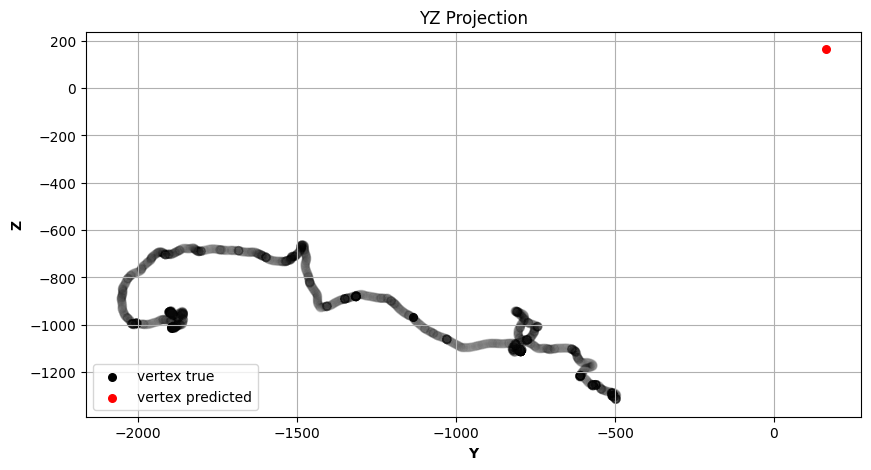

In [32]:
part_df = pd.read_hdf("/mnt/d/events_45_135/simulated_data/1bar/nodiff/nodiff/events_45_135_nexus_780.h5", key="MC/particles")
hits_df = pd.read_hdf("/mnt/d/events_45_135/simulated_data/1bar/nodiff/nodiff/events_45_135_nexus_780.h5", key="MC/hits")

print(hits_df.event_id.dtype)
print(hits_df.event_id.head())
eid = 93816
y_vertex = -1136.418701171875
z_vertex = -967.0194091796875
y_pred = 162.912024
z_pred = 164.70184999999998

event_hits = hits_df[hits_df.event_id == eid].copy()
#event_hits["z"] = event_hits["z"] - z_shift
print(event_hits.head())

fig, ax2 = plt.subplots(figsize=(10, 5))
ax2.scatter(y_vertex, z_vertex, color="black", s=30, label="vertex true")
ax2.scatter(y_pred, z_pred, color="red", s=30, label="vertex predicted")
ax2.scatter(event_hits.y, event_hits.z, alpha=0.02, c=event_hits.energy, cmap="Greys_r")
ax2.set_xlabel("Y", fontweight="bold")
ax2.set_ylabel("Z", fontweight="bold")
ax2.set_title("YZ Projection")
ax2.legend(loc="lower left")
ax2.grid(True)
plt.show()